Upload Dataset From Files

In [53]:
from google.colab import files
up=files.upload()

Saving Churn_Modelling.csv to Churn_Modelling (1).csv


Import Necessary Libraries

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler


In [55]:
df=pd.read_csv("Churn_Modelling.csv")

Write basic Functions

In [56]:
df.shape

(10000, 14)

In [57]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [58]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

Remove Unnecessary Columns

In [59]:
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

In [60]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


Finding Null Values

In [62]:
df.isnull().sum()

,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0


Remove Duplicates From Dataset

In [63]:
df.drop_duplicates(inplace=True)

Visualization

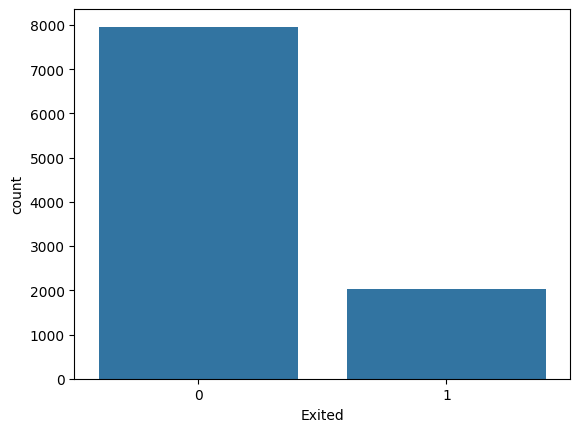

In [64]:
#churn count
sns.countplot(x='Exited', data=df)
plt.show()

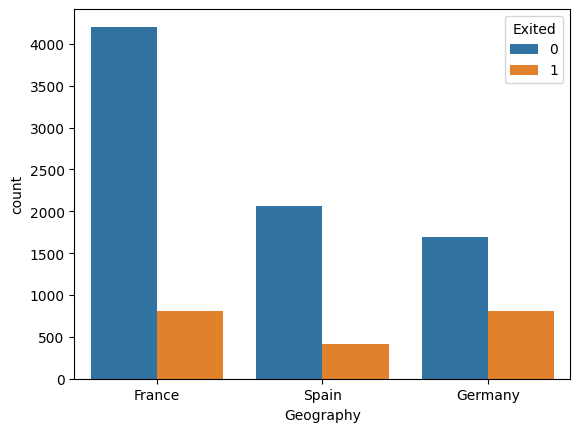

In [65]:
#geography vs Exited
sns.countplot(x='Geography', hue='Exited', data=df)
plt.show()

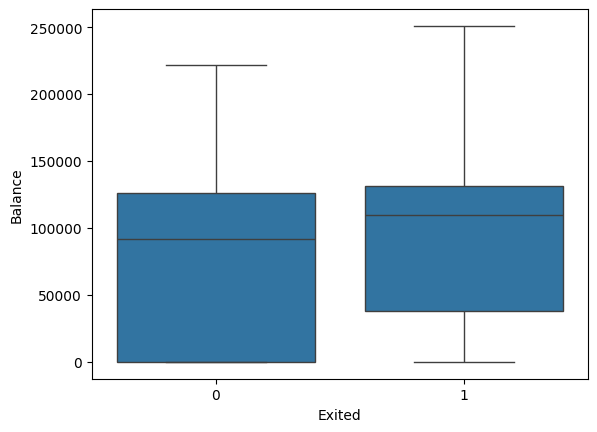

In [66]:
#balance vs exited
sns.boxplot(x='Exited', y='Balance', data=df)
plt.show()

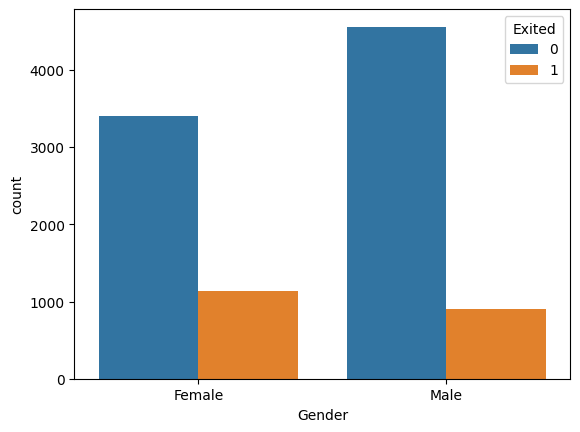

In [67]:
#Gender vs Exited
sns.countplot(x='Gender', hue='Exited', data=df)
plt.show()

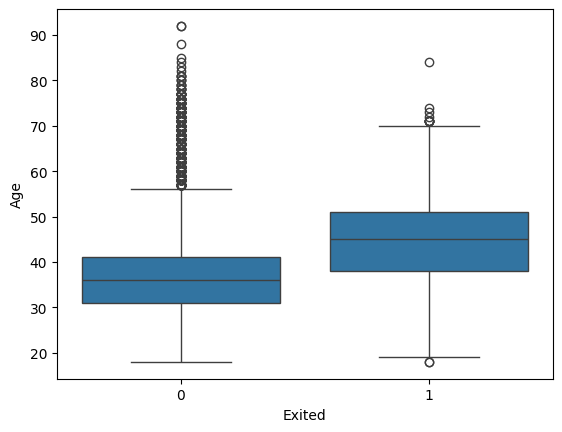

In [68]:
#Age vs Exited
sns.boxplot(x='Exited', y='Age', data=df)
plt.show()

In [69]:
df = pd.get_dummies(df, drop_first=True)

Split Target and Features

In [70]:
X = df.drop('Exited', axis=1)
y = df['Exited']

Split Training and Testing data

In [71]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)


In [76]:
scaler = StandardScaler()

Scaled the Data by StandardScaler

In [77]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

Train the Model

In [78]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

Prediction

In [79]:
y_pred = model.predict(x_test)
print(y_pred)

[0 0 0 ... 0 0 0]


Finding Accuracy

In [74]:
accuracy_score(y_test, y_pred)

0.7865